## Build CCU Gate in QpiAI Explorer Lab on Amazon Braket

In [1]:
#install amazon braket sdk
%pip install amazon-braket-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.8/539.8 kB 13.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 5.0 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.2-py3-none-any.whl size=144548 sha256=e6497d6905f694b844d24

A CCU gate is a three qubit gate in which two qubits act as control while the third qubit is acted with a unitary. To build a CCU gate, we will first implement a controlled-U (CU) gate using first principles and then use this information to construct a CCU gate.

Remember the theorem for designing CU gates that implements the unitary operation $V=R_z(\mu)R_y(\nu)R_z(\eta)$ on the target qubit, we require single qubit operations A, B and C such that:

\begin{eqnarray}
A = R_z(\mu)R_y(\frac{\nu}{2}) \\
B = R_y(\frac{-\nu}{2})R_z(\frac{-\eta-\mu}{2}) \\
C = R_z(\frac{\eta - \mu}{2}) \\
\end{eqnarray}

with $\mu$, $\nu$ and $\eta$ being angles of rotations in radians.

In [2]:
# Create general imports:

import numpy as np
import matplotlib.pyplot as plt

# Create AWS imports:

from braket.circuits import Circuit, Gate
from braket.devices import LocalSimulator

In [3]:
# Assign rotation angles:

rn = np.random.rand(3,1)
mu = 2*np.pi*rn[0]
nu = 2*np.pi*rn[1]
eta = 2*np.pi*rn[2]

print(rn)


[[0.28515562]
 [0.41412787]
 [0.24986293]]


Now we define the function that implements the CU gate and its adjoint using $\mu,\nu$  and $ \eta$ as inputs.For more details of implementation please refer to the video tutorials.

In [4]:
# Construct a CU gate:

def CU(mu, nu, eta):

    # Generate the quantum circuit:

    CU = Circuit()

    # Apply operation C on the qubit 1

    CU.rz(1, (eta-mu)/2)

    # Apply CNOT on the circuit with control qubit 0 and target qubit 1

    CU.cnot(0, 1)

    # Apply operation B on the qubit 1

    CU.ry(1, -nu/2).rz(1, -(eta + mu)/2)

    # Apply CNOT on the circuit with control qubit 0 and target qubit 1

    CU.cnot(0, 1)

    # Apply operation A on the qubit 1

    CU.rz(1, mu).ry(1, nu/2)

    return CU

In [5]:
# Construct the Adjoint of CU:

CU_adjoint = CU(mu, nu, eta).adjoint()


### Construct the CCU Gate

Now, we will construct the circuit for implementing the CCU Gate that implements the unitary $U=V^2$ on the target qubit being controlled by two other qubits. We will use the CU Gate and its adjoint constructed above for this purpose. For more details of implementation please refer to the video tutorials.

In [6]:
# Construct the CCU circuit:

def CCU(initial_state):

    CCU = initial_state

    #Apply CU Gate with control qubit 1 and target qubit 2

    CCU.add_circuit(CU(mu, nu, eta), [1, 2])

    # Apply CNOT with control qubit 0 and target qubit 1

    CCU.cnot(0, 1)

    #Apply the adjoint of CU with control qubit 1 and target qubit 2

    CCU.add_circuit(CU_adjoint, [1, 2])

    # Apply CNOT on the circuit with control qubit 0 and target qubit 1

    CCU.cnot(0, 1)

    #Apply CU Gate with control qubit 0 and target qubit 2

    CCU.add_circuit(CU(mu, nu, eta), [0, 2])

    return CCU

### Test the CCU gate

Counts:  Counter({'000': 999, '001': 1})


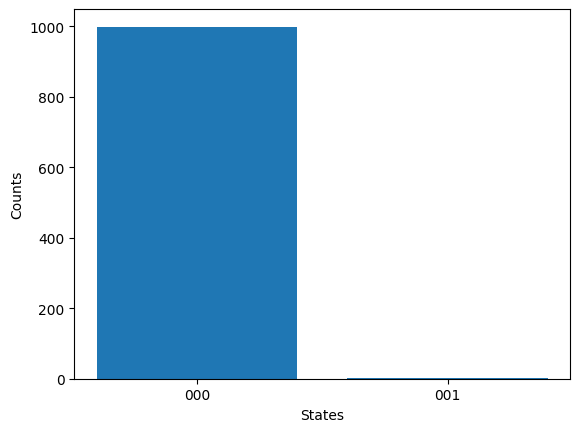

In [7]:
# Set up the device:

device = LocalSimulator()

# Run the circuit. We have tested it by acting with CCU on a |000> state. We can test it by running
# over different states also for example the GHZ state.

initial_state = Circuit()
CCU_test = CCU(initial_state)

result = device.run(CCU_test, shots=1000).result()

# Get measurement shots:

counts = result.measurement_counts

# Print the counts

print("Counts: ", counts)

# Plot the results using counts:

plt.bar(counts.keys(), counts.values())
plt.xlabel('States')
plt.ylabel('Counts')
plt.show()